::: {.hidden}
$$
\gdef\rvar#1{\mathrm{#1}}
\gdef\rvec#1{\mathbf{#1}}
\gdef\vec#1{\boldsymbol{#1}}
\gdef\tens#1{\boldsymbol{\mathsf{#1}}}
\gdef\tensel#1{\mathsf{#1}}
\gdef\st#1{\mathcal{#1}}
\gdef\diag#1{\mathrm{diag}(\vec{#1})}
$$
:::

In [2]:
# Setup for Google Colab
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('dl_course'):
        !git clone -q --depth 1 https://github.com/konstantin-schekotihin/dl_course.git
    %cd -q /content/dl_course/03_DL
    !pip install -q torch-geometric wandb

# some initialization stuff
%run ../init.py
%matplotlib inline

import nns.helpers as hp
from nltk.corpus import wordnet as wn
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import SVC

import nns.helpers as hp

<IPython.core.display.Latex object>

# Introduction

- Which architecture should I use?
    - *Computer vision* - CNNs
    - *Natural language processing* - RNN, LSTM, GRU
    - *Speech* - Deep belief networks
    - *Machine translation* - Seq2Seq
    - *Reinforcement learning* - Deep ANNs in combination with DDQN or PPO

<div class="myalert"> <b>Transformer</b>, nowadays, is applied everywhere!</div>

# Natural Language Processing

<hr>
The art of manipulating symbols with subsymbolic AI

## How is the meaning of a word defined?

- *Dictionary* - how a community of speakers agrees to use it
    - Even the largest dictionaries may not define all meanings of all words
    - bank (finance) and bank (geography)
- *Reference Theory (Semantics)* - what it refers to in the world, i.e., some object
    - Issues with mental concepts, e.g., unicorn
    - "We went to a bank" vs "We sat on a bank" 
- *Conceptual / Cognitive Approach* - link words to their mental concepts, e.g., bank - institutions, money, deposits, withdrawals.
    - The meaning of the word is defined only ambiguously
- *Use Theory (Wittgenstein)* - the meaning of a word is defined by its use in the communication
    - Considering all possible contexts in which a word is used may be hard
    - in the financial context, "bank" means an institution and in the geographical - riverbank

## Can computers capture the meaning?

- Classic solution was to create a large dictionary capturing everything we know about the language (deductive approach)

In [3]:
# find sets of word synonyms

word = wn.synsets("game")
poses = {'n':'noun','v':'verb','s':'adj(s)','a':'adj','r':'adv'}
for synset in word:
    print("{}: {}"
          .format(poses[synset.pos()], ", "
                  .join([l.name() for l in synset.lemmas()])))

noun: game
noun: game
noun: game
noun: game
noun: game
noun: game
noun: game
noun: plot, secret_plan, game
noun: game
noun: game, biz
noun: game
verb: bet_on, back, gage, stake, game, punt
adj(s): crippled, halt, halting, lame, gimpy, game
adj(s): game, gamy, gamey, gritty, mettlesome, spirited, spunky


In [4]:
# find categories into which words with more specific meanings fall

word = wn.synset("game.n.01")
hyper = lambda s: s.hypernyms()
list(word.closure(hyper))

[Synset('activity.n.01'),
 Synset('act.n.02'),
 Synset('event.n.01'),
 Synset('psychological_feature.n.01'),
 Synset('abstraction.n.06'),
 Synset('entity.n.01')]

### Issues with deductive NLP

- WordNet and similar resources are very useful for linguists
- Major issues in computer applications
    - Cannot differentiate between contexts in which a word is used
    - Does not return any coverage of the connotations or appropriateness of words
    - Often missing meanings of new, slang, or dialect words
    - May contain subjective definitions of a single expert (same issues as on Wikipedia)
    - Cannot be used to manipulate word, e.g., compute similarity between words
    
- Most important, it is **impossible** to keep them up-to-date

## Representations of words

- Humans and traditional NLP consider words as discrete symbols
- Computers store symbols using numerical representations
    - `U+1F600` is a code corresponding to a 😀 smiley
    - "hotel" is represented in ASCII as a vector of 
        - hexadecimal numbers `(68, 6F, 74, 65, 6C)` or 
        - binary `01101000 01101111 01110100 01100101 01101100`

In [5]:
ohe = OneHotEncoder()
#X=[["hotel"], ["motel"], ["model"]]
X=[["h","o","t","e","l"], 
   ["m","o","t","e","l"], 
   ["m","o","d","e","l"]]

X_v = ohe.fit_transform(X).toarray()
print("One-hot enoding of the input: \n", X_v)
print("Cosine similarity matrix of obtained vectors: \n", 
      cosine_similarity(X_v, X_v))

One-hot enoding of the input: 
 [[1. 0. 1. 0. 1. 1. 1.]
 [0. 1. 1. 0. 1. 1. 1.]
 [0. 1. 1. 1. 0. 1. 1.]]
Cosine similarity matrix of obtained vectors: 
 [[1.  0.8 0.6]
 [0.8 1.  0.8]
 [0.6 0.8 1. ]]


## Representation of documents

- A classic approach to document vectorization is to represent them as **bags of words**
    - The meaning of the document is determined only by the used words
    - The order of the words does not matter
    - A "word" is not necessarily a word in the common sense $\Leftarrow$ token
- Common algorithms include three steps
    - Tokenization: determine a vocabulary of tokens and assign them an integer ID
    - Computation of statistics: frequency of tokens' use in each document
    - Normalization: avoid giving high scores to outliers, e.g., very (in)frequently used tokens

In [6]:
corpus = [
    'We stopped at the hotel.',
    'We stopped by a motel.',
    'We stopped the model.',
]

vectorizer = CountVectorizer(analyzer="word", ngram_range=(1, 3))
X = vectorizer.fit_transform(corpus)

print("Computed dictionary of tokens:", 
      vectorizer.get_feature_names_out(), "\n")
print("Obtained vectors for every string:\n", 
      X.toarray(), "\n")
print("Cosine similarity matrix of obtained vectors: \n", 
      cosine_similarity(X.toarray(), X.toarray()))

Computed dictionary of tokens: ['at' 'at the' 'at the hotel' 'by' 'by motel' 'hotel' 'model' 'motel'
 'stopped' 'stopped at' 'stopped at the' 'stopped by' 'stopped by motel'
 'stopped the' 'stopped the model' 'the' 'the hotel' 'the model' 'we'
 'we stopped' 'we stopped at' 'we stopped by' 'we stopped the'] 

Obtained vectors for every string:
 [[1 1 1 0 0 1 0 0 1 1 1 0 0 0 0 1 1 0 1 1 1 0 0]
 [0 0 0 1 1 0 0 1 1 0 0 1 1 0 0 0 0 0 1 1 0 1 0]
 [0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 1 0 1 1 1 0 0 1]] 

Cosine similarity matrix of obtained vectors: 
 [[1.         0.28867513 0.38490018]
 [0.28867513 1.         0.33333333]
 [0.38490018 0.33333333 1.        ]]


### Weighted representations

- In large text corpora there are many outliers
    - "a" or "the", etc., are used very often
    - "anachronism" or "cacophony" are very rare
- Assumption: Outliers capture less or no semantics of the document
- *Tf-Idf*: term-frequency - inverse document-frequency is a popular approach to text vectorization
    - $\text{tf(t,d)}$ - how often the token $t$ is used in the document $d$
    - $\text{idf(t)}$ - measures the importance of the token in the whole collection, where $n$ is the total number of documents, and $\text{df}(t)$ is the number of documents that contain $t$

$$\text{tf-idf(t,d)}=\text{tf(t,d)} \cdot \text{idf(t)}$$
$$\text{idf}(t) = \log{\frac{1 + n}{1+\text{df}(t)}} + 1$$


In [12]:
corpus = [
    'We stopped at the hotel.',
    'We stopped by a motel.',
    'We stopped the model.',
    'The model stopped.'
]

vectorizer = TfidfVectorizer(analyzer="word", ngram_range=(1, 2))
X = vectorizer.fit_transform(corpus)

print("Computed dictionary of tokens:", 
      vectorizer.get_feature_names_out(), "\n")
print("Obtained vectors for every string:\n", 
      X.toarray(), "\n")
print("Cosine similarity matrix of obtained vectors: \n", 
      cosine_similarity(X.toarray(), X.toarray()))

Computed dictionary of tokens: ['at' 'at the' 'by' 'by motel' 'hotel' 'model' 'model stopped' 'motel'
 'stopped' 'stopped at' 'stopped by' 'stopped the' 'the' 'the hotel'
 'the model' 'we' 'we stopped'] 

Obtained vectors for every string:
 [[0.39239682 0.39239682 0.         0.         0.39239682 0.
  0.         0.         0.20476894 0.39239682 0.         0.
  0.25046181 0.39239682 0.         0.25046181 0.25046181]
 [0.         0.         0.44336682 0.44336682 0.         0.
  0.         0.44336682 0.2313672  0.         0.44336682 0.
  0.         0.         0.         0.2829953  0.2829953 ]
 [0.         0.         0.         0.         0.         0.40780138
  0.         0.         0.26991956 0.         0.         0.51724434
  0.33015036 0.         0.40780138 0.33015036 0.33015036]
 [0.         0.         0.         0.         0.         0.46115286
  0.58491393 0.         0.30523235 0.         0.         0.
  0.37334298 0.         0.46115286 0.         0.        ]] 

Cosine similarity ma

In [7]:
# Label encoding: 1 - traveling, 2 - computer science
y = [1,1,2,2]

svc = SVC(gamma='auto')
svc.fit(X,y)

new_str="We run the hotel"
vec = vectorizer.transform([new_str])
print(new_str, "- class:", svc.predict(vec), vec.toarray())

We run the hotel - class: [1] [[0.         0.         0.74230628 0.         0.         0.
  0.47380449 0.47380449]]


In [8]:
# Issues with unknown words <unk>

vectorizer.transform(["runs"]).toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0.]])

## Subword tokenization

- Byte-Pair Encoding (BPE)
    - Split the training data into words
    - Form a vocabulary of characters from the text
        - `"hotel": 100, "motel" : 50, "model": 10` $\Rightarrow$ vocabulary `d e h l m o t`
    - Split the words into symbols of the vocabulary
        `(h o t e l): 100, (m o t e l) : 50, (m o d e l): 10`
    - Count the frequency of each possible symbol pair and take the most frequent one
        - `el` occurs 160 times $\Rightarrow$ `'el'` is added to the vocabulary `d e h l m o t 'el'`
        - Retokenize the text `(h o t 'el'): 100, (m o t 'el'): 50, (m o d 'el'):10`
- The idea is very similar to agglomerative clustering

<div class="cite">Neural Machine Translation of Rare Words with Subword Units (Sennrich et al., 2015) </div>

## Subword tokenization

- *WordPiece*: merge by likelihood as measured by language model, not by frequency
- *Unigram*: initializes its base vocabulary to a large number of symbols and progressively trims down each symbol to obtain a smaller vocabulary
- *SentencePiece*: includes the space in the initial vocabulary and uses the BPE or Unigram algorithm to construct the appropriate vocabulary
- [LLM Tokenizers](https://tiktokenizer.vercel.app/)

<div class="cite"> SentencePiece: A simple and language independent subword tokenizer and detokenizer for Neural Text Processing (Kudo et al., 2018) </div>

## Long-term dependencies

- The idea of focusing on relevant parts of input is not new to neural networks
    - Convolutional layers of CNNs focus on a fixed part of an input
    - Graph Neural Networks consider neighborhood of a node
- All these architectures, nevertheless, focus on a rather *short-term dependencies*
- Many tasks require memorization of long-term dependencies between parts of input
    - Text classification: selection of a label might depend on the words located in distant positions in the text
    - Speech-to-text: any output word might depend on the context, i.e., meaning of the whole recorded sound

## Encoder-Decoder Architecture

- The architecture comprises two components:
    - Encoder is a stochastic mapping of an input sequence to a state representing its features
    - Decoder maps the representation to an output sequence
- Early applications in the dimensionality reduction or representation learning
    - Input representation simplifies the extraction of useful information when building classifiers or other predictors

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/Transformers-Enc-Dec.svg" width="60%"/>
</center>

<div class="cite">LeCun (1987). Modèles connexionistes de l’apprentissage. Ph.D. thesis</div>

## Seq2Seq Background

- Transformers emerged in the field of sequence modeling and transduction
    - Any task where input sequences are transformed into output sequences
    - Input and output sequences can be of arbitrary (non-equal) length
- Leading problem was *Machine Translation*
    - *Given* an input sequence of words in the source language 
    - *Output* a corresponding sequence of words in the target language

## Seq2Seq Learning


- Encoder and decoder use deep LSTMs
    - Encoder generates a large fixed-dimensional vector representation
    - Decoder is a language model conditioned on the input sequence

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/Transformers-Seq2Seq.svg" width="60%"/>
</center>

<div class="cite">
Sutskever at al. (2014). Sequence to Sequence Learning with Neural Networks<br/>
Cho et al. (2014). Learning phrase representations using RNN encoder-decoder for statistical machine translation.
</div>

## Seq2Seq issues

- Multiple issues with training of RNNs
    - Despite much research, training of RNNs is still challenging, especially for large data sets
    - Shallow RNNs cannot capture long-term dependencies 
    - Deep RNNs still have issues with vanishing/exploding gradients and inefficient non-scalable training methods
- **Encoder bottleneck**: All information about the input sequence must be packed in the last hidden state
    - Often, too much information must be compressed into a single vector

# Attention mechanism for the decoder

- **Idea**: let the decoder emulate and associative search through annotations of the input sequence

In [9]:
from difflib import SequenceMatcher

def search(query, enc):
    v = 0
    print("Query '{}'".format(query))
    for key in enc.keys():
        s = SequenceMatcher(None, query, key).ratio()
        v += s * enc[key]
        print("Key '{}', similarity {:.3f}, value {}, combined {:.3f}".format(key, s, enc[key], s * enc[key]))

    print("Resulting value: {:.3f}\n".format(v))

In [10]:
enc1 = {"black": 100, "big" : 50, "pan": 10}

search("bank", enc1)
search("pal", enc1)

Query 'bank'
Key 'black', similarity 0.667, value 100, combined 66.667
Key 'big', similarity 0.286, value 50, combined 14.286
Key 'pan', similarity 0.571, value 10, combined 5.714
Resulting value: 86.667

Query 'pal'
Key 'black', similarity 0.250, value 100, combined 25.000
Key 'big', similarity 0.000, value 50, combined 0.000
Key 'pan', similarity 0.667, value 10, combined 6.667
Resulting value: 31.667



## Additive attention - the original idea

- Compute a "personalized" context for every application of the decoder RNN
- Use bidirectional RNNs for the encoder
    - Generate annotations $\vec{h}_j = [\overleftarrow{\vec{h}}_j;\overrightarrow{\vec{h}}_j]$
    - Probabilities $\alpha_{ij} = \text{softmax}(\text{am}(\vec{s}_{i-1},\vec{h}_j))$
        - importance of an annotation for output generation wrt. the previous hidden state 
        - $\text{am}$ is an arbitrary function measuring the similarity between the query and the keys 
- Context vector
$$\vec{c}_i = \sum_{1\leq j \leq T} \alpha_{ij}\vec{h}_j$$

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/Transformers-Attention.svg" width="60%"/>
</center>

## Associative dictionary
- In the original paper, attention is represented as:
    - Query $\vec{q}_i$ : previous state of a decoder $\vec{s}_{i-1}$
    - Key $\vec{k}_j$ :  a state of an encoder $\vec{h}_j$ (annotation)
    - Value $\vec{v}_j$ : a state of an encoder $\vec{h}_j$
    
    $$\vec{c}_i = \sum_{1\leq j \leq T} \text{softmax}(\text{am}(\vec{q}_{i},\vec{k}_j))\vec{v}_j$$

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/Transformers-Attention-ex.svg" width="60%"/>
</center>

<div class="cite">
Bahdanau et al. (2014). Neural Machine Translation by Jointly Learning to Align and Translate
</div>

## Similarity/scoring functions $\text{am}$

- Let the key $\vec{k}_j$ and the query $\vec{q}_i$ represent the hidden states of the encoder and the decoder, respectively
    - **Additive** (original): the similarity function is a *soft alignment* model 
        - Feed-Forward Network with weights $\vec{W}_a$
        - Also called "concatenation" attention in the literature
    $$\text{am}(\vec{q}_{i},\vec{k}_j) = \tanh(\vec{W}_a[\vec{q}_{i}; \vec{k}_j])$$
  

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/scoring_functions.svg" width="40%"/>
</center>

- $\alpha_{ij} \geq 0$ - the output is in a convex cone spanned by the vectors $\vec{v}_i$
- $\sum_j \alpha_{ij} = 1$, the weights form a convex combination - most common setting in DL obtained using, e.g., the softmax function
    - if only one $\alpha_{ij} = 1$ for every query $\vec{q}_{i}$ - traditional database queries
    - all $\alpha_{ij} = 1/m$ - averaging across the database or average pooling

## Similarity/scoring functions $\text{am}$, cont'd

- There are many variants of the scoring function in the literature
    - **Content-based** ([Graves et al.](https://arxiv.org/abs/1410.5401)): the similarity is measured as a cosine of an angle between vector representations of the encoder-decoder hidden states $$\text{am}(\vec{q}_{i},\vec{k}_j) = \cos(\vec{q}_{i},\vec{k}_j)$$ 
    - **Location-based** ([Luong et al.](https://arxiv.org/abs/1508.04025)): the softmax alignment to only depend on the target position $$\text{am}(\vec{q}_{i},\vec{k}_j) = \vec{W}_a \vec{k}_j$$ 
    - **General** (Luong et al.): $\vec{W}_a$ is a trainable weight matrix in the attention layer $$\text{am}(\vec{q}_{i},\vec{k}_j) = \vec{q}_i^\top\vec{W}_a\vec{k}_j$$    
    - **Dot-product** (Luong et al.): , similar to the content-based but takes also the length of vectors into account $$\text{am}(\vec{q}_{i},\vec{k}_j) = \vec{q}_i^\top\vec{k}_j$$    

### Scaled dot-product ([Vaswani et al.](https://arxiv.org/abs/1706.03762))

$$\text{am}(\vec{q}_{i},\vec{k}_j) = \frac{\vec{q}_i^\top\vec{k}_j}{\sqrt{d}}$$

- The scaling factor refers to the dimension $n$ of the input hidden state to compensate for small gradients of *softmax* given large inputs sequences
    - Let all the elements of $\vec{k}_j, \vec{q}_i \in \mathbb{R}^d$ are iid with zero mean and unit variance
    - Then, $\vec{q}_i^\top\vec{k}_j$ has also zero mean and $n$ variance
    - The normalization factor $\frac{1}{\sqrt{d}}$ ensures that the result $\text{am}(\vec{q}_{i},\vec{k}_j)$ has unit variance

### General form

- Let $\vec{Q} \in \mathbb{R}^{n\times d}$, $\vec{K} \in \mathbb{R}^{m\times d}$, and $\vec{V} \in \mathbb{R}^{m\times v}$ be collections of queries, keys, and values, respectively

$$
\vec{A}(\vec{Q},\vec{K},\vec{V}) = \text{softmax}(\text{am}(\vec{Q},\vec{K}))\vec{V}
$$

- where rows of the attention matrix $\vec{A}(\vec{Q},\vec{K},\vec{V})$ represent all context vectors describing relations between queries and values ($n\times v$)
- In the case of scaled dot-attention 
$$\text{am}(\vec{Q},\vec{K}) = \frac{\vec{Q}\vec{K}^\top}{\sqrt{d}}$$

## Training additive attention

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/additive-idea.svg" width="60%"/>
</center>

## Application variants

- Self-attention $\vec{Q}=\vec{K}=\vec{V}$
    - for each query – there – we create 4 key-value pairs of all other words, like (let, let)
    - has the shortest maximum path length

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/Transformers-self-attention.svg" width="60%"/>
</center>

In [11]:
enc2 = {"100": 100, "50" : 50, "10": 10}

search("10", enc2)

Query '10'
Key '100', similarity 0.800, value 100, combined 80.000
Key '50', similarity 0.500, value 50, combined 25.000
Key '10', similarity 1.000, value 10, combined 10.000
Resulting value: 115.000



## Application variants, cont'd

- Multi-head attention - every head can learn different dependencies for the same query-key-value input
    - use various representations of queries, keys, and values
    - parallel operations

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/Transformers-Multi-head.svg" width="60%"/>
</center>

## Positional encoding

- RNNs are the first choice for the creation of queries, keys, and values
    - developed to work with sequences
    - sequential approach prohibits parallelization during training
- The attention mechanism ignores positions
    - *Horses eat apples* is equivalent to *Apples eat horses*
    
- Add positional information to every embedding vector

## Positional encoding, cont'd

- Original idea is to use different trigonometric functions to introduce a unique and position dependent shift to every vector
- Every input token is represented by a vector with $d_t$ dimensions 
- Given a position of an input token $p$ and the number of a component in the embedding vector $i$
$$
\mathit{PE}(p,i) = \left\{\begin{matrix}
 \sin(T(p,i)), & i \text{ is even } \\ 
 \cos(T(p,i)), & i \text{ is odd }
\end{matrix}\right.
$$

     where the $T(p,i)$ is defined to avoid collisions due to repeating position shifts

$$T(p,i) = \frac{p}{10000^{i/d_t}}$$

### Example: positional encoding of the third word

The embedding vector $\mathit{go} = [\mathit{go}_1, \mathit{go}_2, \mathit{go}_3, \mathit{go}_4]$ with $d_t=4$ of the word *go* is encoded like

$$
\begin{align}
\mathit{go}_{PE} &= \mathit{PE}(3) + \mathit{go} \\
 &= [-0.856, 0.778, -0.368, 1] + [\mathit{go}_1, \mathit{go}_2, \mathit{go}_3, \mathit{go}_4] \\
 &= [\mathit{go}_1 - 0.856, \mathit{go}_2+0.778, \mathit{go}_3-0.368, \mathit{go}_4+1]
\end{align}
$$

where every $i$-th component of the $\mathit{PE}(3)$ is computed using the $\mathit{PE}(p,i)$ , e.g., $\mathit{PE}(3,1)=-0.856$ for the first component $i=1$


<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/attachment:image-2.png" width="50%"/>
</center>
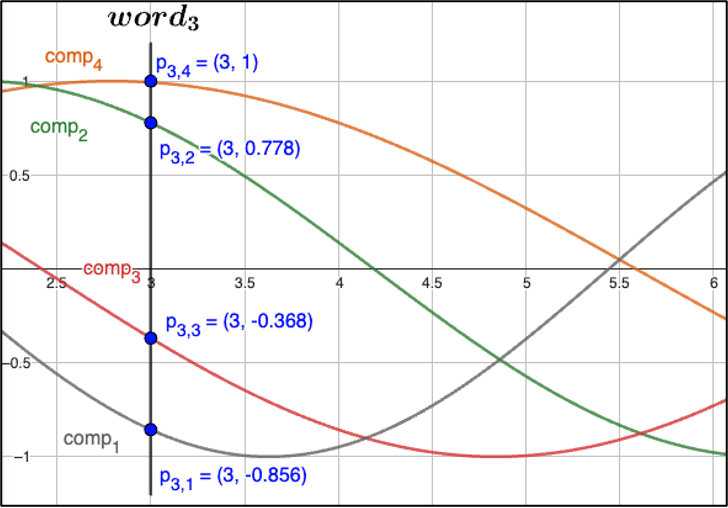

## Skip connections and layer normalization

- Outputs of *residual blocks* have the same dimensions as inputs
$$\vec{o}_i = \textrm{Block}(\vec{x}_i) + \vec{x}_i$$
    - Computes a *residual* instead of a new value
    - Helps to avoid the vanishing gradient problem and improve trainability
- Layer normalization 
    - Applies scaling and offset element-wise, i.e., $\hat{\mu_i}$ and $\hat\sigma_i$ are computed for components of $\vec{x}_i$ 
$$\mathit{LN}(\vec{x}_i) =  \frac{\vec{x}_i - \hat{\mu_i}}{\hat\sigma_i}$$
    - Post-normalization
$$\vec{o}_i = \mathit{LN}(\textrm{Block}(\vec{x}_i) + \vec{x}_i)$$
    - Pre-normalization
$$\vec{o}_i = \textrm{Block}(\mathit{LN}(\vec{x}_i)) + \vec{x}_i$$

# Transformer architecture

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/transformer.svg" width="40%"/>
</center>

# Pretraining

<hr>
The power of foundational models

## Transformer pretraining

- Pretraining a tokenizer is not really useful
    - Embeddings are generated independently of the context 
        - "We play the play." - "play" is always mapped to the same token
    - The meaning of a word cannot be determined outside of its context
        - Dictionaries often have multiple entries for the same word
    - Training does not focus on any downstream task, e.g., classification

- Modern NLP focuses on pretraining of the whole model
    - **Unsupervised pretraining**: Learn general knowledge from *huge* text corpora
        - *Idea*: hide parts of the input, and train the model to reconstruct them
        - Horses _____ apples
        - The Fibonacci sequence is defined as follows 1,1,2,3,5, ___
    - **Fine-tuning** on the downstream task: Adapt to the task in (mostly) supervised settings from *few* examples
        - Horses eat apples $\Rightarrow$ (Animals)

## Transformer pretraining

<hr>
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/Transformer-training.svg" width="80%"/>
</center>

## Pretraining encoders - BERT

- Bidirectional encoder representations from transformers (BERT)
    - *Idea*: replace some (around 15%) input tokens with a special [MASK] token following the rules:
        - Replace input word with [MASK] 80% of the time
        - Replace input word with a random token 10% of the time (red)
        - Leave input word unchanged 10% of the time (but still predict it! - blue)
    - Compute the loss only with respect to the masked tokens

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/Transformers-BERT.svg" width="60%"/>
</center>

## Pretraining encoders - BERT

- Two models were released by [Devlin et al., 2018](https://arxiv.org/pdf/1810.04805.pdf):
    - BERT-base:  12 layers, 110M, 12 attention heads, 768-dim hidden states
    - BERT-large: 24 layers, 340M, 16 attention heads, 1024-dim hidden states 
- Model was trained on:
    - BooksCorpus (800M words)
    - English Wikipedia (2,5B words)
- Pretraining a BERT model required much resources
    - 64 TPUs (Tensor Processing Unit) for a total of 4 days
- Fine-tuning can be done a single GPU (depends on VRAM)
    - Massive popularity due to simple downstream task adaptation and high performance
    - Many variants, like RoBERTa (simplified and longer training) or SpanBERT (mask contiguous spans of words)
- *Limitation*: unsatisfactory performance in generative settings

## Pretraining encoder-decoder - T5

- Idea: Split the input into 2 parts - prefix and training
    - Provide prefix to the encoder as is
    - Use *span corruption* to modify the training part
        - Replace different-length spans from the training input with *unique* placeholders and predict them
        - Forces the decoder to output short sequences of different length for every span
- T5 can be fine-tuned to answer various types of questions by [Raffel et al., 2018](https://arxiv.org/pdf/1910.10683.pdf)
    - Evaluated models Base (220M), Large (770M), XL (3B), XXL (11B)
    - State-of-the-art (2018) performance on Natural Questions, Web Questions, and Trivia QA datasets   

## Pretraining decoders

- All the biggest pretrained models are **decoders**!
- *Predict the next token* - basis of Generative AI
- Generative Pretrained Transformer (GPT) by [Radford et al., 2018](https://www.cs.ubc.ca/~amuham01/LING530/papers/radford2018improving.pdf) - the source of the acronym is unknown :)
    - GPT in 2018, 117M, 12 layers, 768 hidden state and 3072 feed-forward hidden dimensions
    - BPE with a limit of 40,000 merges
    - Training data generated from over 7000 unique books focusing on long spans of contiguous text to increase the length of dependencies
    - Fine-tuning for various tasks
    - Natural Language Inference: Determine if the first statement is contradicts/neutral/entails the second one
        - [START] At the other end of Pennsylvania Avenue, people began to line up for a White House tour.
        - [DELIM] People formed a line at the end of Pennsylvania Avenue. [EXTRACT]
        - Goal is to predict [entails] for the [EXTRACT] token
        

## Pretraining decoders

- GPT2 (1.5B) by [Radford et ak., 2019](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) trained on more data than GPT was able to 
    - Generate pretty interesting texts
        - *Context*: "... In Cygwin on Windows I found that I could not set the permissions of my /.ssh/ folder to be 0600, as is required for ssh to allow you to use keys. The symptom I had was that I no matter what I did, it always modified the owner and the group"
        - *GPT2 completion*: ", making these files read-only. I tried just starting ssh and using a program like passwd which modifies the owner/group to 0644 permissions, but it didn’t work. ..."
    - Answer questions:
        - "Who wrote the book the origin of species?" GPT2:"Charles Darwin" - Correct - Probability: 83.4%
        - "Largest state in the us by land mass?" GPT2:"California" - Incorrect - Probability: 59.2%
        

## Pretraining decoders

- GPT3 (175B) trained on 300B tokens excelled in the *in-context learning*
    - Previous models were used to sample from distributions over tokens and fine-tune for downstream tasks
    - GPT3 is able to perform some kind of learning without explicit fine-tuning updating weights of the network
    - The in-context examples describe the task and conditional distribution captured by the network simulates its execution
    - The era of prompting is born 😀